# Computer Vision: scikit-image + scikit-learn

![](python-logo.png)
![](logo.png)
![](scikit-learn-logo-small.png)

# Problema: 
## Classificar Imagens da Retina
#### *Com Retinopatia* 

#### *Sem Retinopatia*


In [25]:
import numpy as np
from numpy import copy
import matplotlib.pyplot as plt
from skimage.io import imread_collection,imsave
from sklearn.model_selection import train_test_split
from glob import glob
from scipy.stats import randint as sp_randint
import time
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label,regionprops
import copy
from scipy.stats.mstats_basic import skew, kurtosis
from IPython.display import clear_output
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")




# Read images from database

In [26]:
path = "RIMONE-db-r2/"

In [27]:
benigno = glob(path+'benigno/*.jpg')

In [28]:
print('A base de imagens da retina possui {} exemplos benignos.'.format(len(benigno)))

A base de imagens da retina possui 255 exemplos benignos.


In [29]:
maligno = glob(path+'maligno/*.jpg')

In [30]:
print('A base de imagens da retina possui {} exemplos malignos.'.format(len(maligno)))

A base de imagens da retina possui 200 exemplos malignos.


In [31]:
images = imread_collection(benigno+maligno)

Text(0.5, 1.0, 'Exemplo de imagem da base')

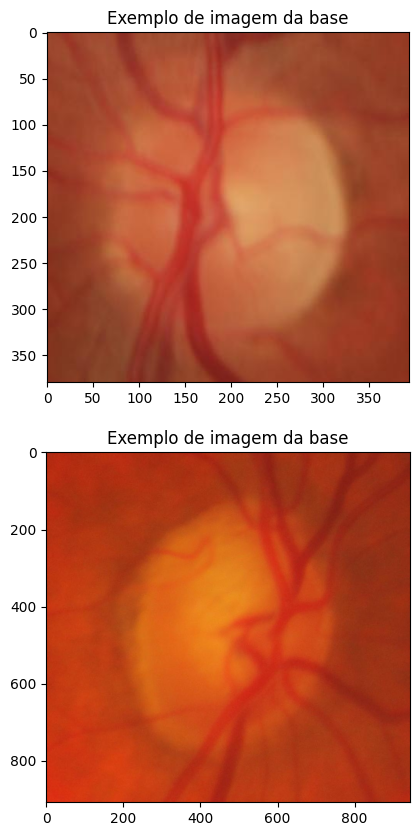

In [32]:
fig, ax = plt.subplots(2,1,figsize=(10,10))
ax[0].imshow(images[0])
ax[0].set_title('Exemplo de imagem da base')
ax[1].imshow(images[350])
ax[1].set_title('Exemplo de imagem da base')

In [33]:
labels = np.concatenate((np.zeros(len(benigno)),np.ones(len(maligno))))
len(labels)

455

# Extracting Features using GLCM

In [34]:
from skimage.feature import graycomatrix,graycoprops

### Parameter

- Distance
- Angle

In [35]:
d = 2

In [36]:
features = np.zeros((len(labels),18)) #6 features x 3 color channels
start = time.time()

for id_im,imagem in enumerate(images):
    clear_output(wait=True)
    print('Extraindo atributos: {} imagens processadas de {}.'.format(id_im+1,len(images)))
    for id_ch in range(3):
        matrix0 = graycomatrix(imagem[:,:,id_ch], [d], [0],normed=True)
        matrix1 = graycomatrix(imagem[:,:,id_ch], [d], [np.pi/4],normed=True)
        matrix2 = graycomatrix(imagem[:,:,id_ch], [d], [np.pi/2],normed=True)
        matrix3 = graycomatrix(imagem[:,:,id_ch], [d], [3*np.pi/4],normed=True)
        matrix = (matrix0+matrix1+matrix2+matrix3)/4 #glcm isotropica
        props = np.zeros((6))
        props[0] = graycoprops(matrix,'contrast')[0,0]
        props[1] = graycoprops(matrix,'dissimilarity')[0,0]
        props[2] = graycoprops(matrix,'homogeneity')[0,0]
        props[3] = graycoprops(matrix,'energy')[0,0]
        props[4] = graycoprops(matrix,'correlation')[0,0]
        props[5] = graycoprops(matrix,'ASM')[0,0]
        features[id_im,id_ch*6:(id_ch+1)*6] = props

end = time.time()
print(end - start)

Extraindo atributos: 455 imagens processadas de 455.
10.935076236724854


# Visualizando os atributos

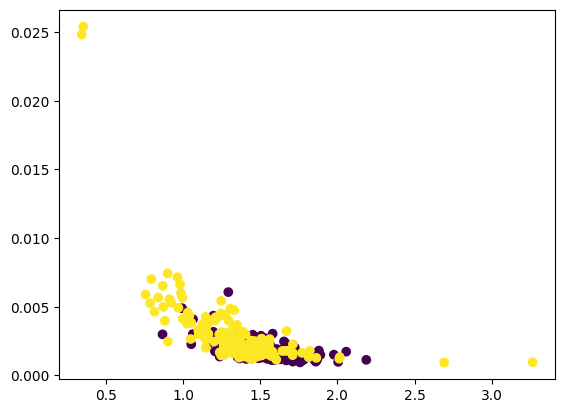

In [37]:
plt.scatter(features[:,1],features[:,5],c=labels)

In [38]:
pca = PCA()
pca.fit(features)
transform = pca.transform(features)
print(np.sum(pca.explained_variance_ratio_[0:3]))

0.9971816252950451


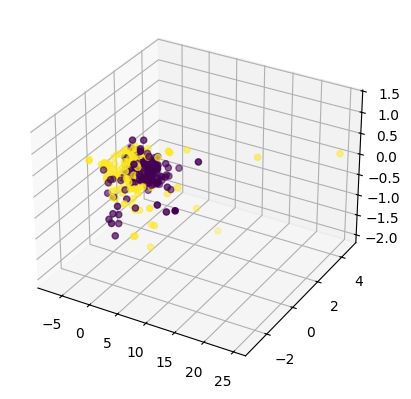

In [39]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(transform[:,0],transform[:,1],transform[:,2],c=labels)

# Classification

- Dividir o espaço de atributos em regiões;
- A quantidade de regiões é o número de classes;
- A acurácia da classificação está diretamente liga à qualidade dos atributos.

### Split Data

In [40]:
train = 0.7
test = 1-train #0.3

In [41]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=test)

### Train/Test

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import cohen_kappa_score, make_scorer, confusion_matrix,accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [43]:
#c_rf = RandomForestClassifier(n_estimators=1000)
c_rf = AdaBoostClassifier()
c_rf.fit(X_train,y_train)
pred = c_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred)
print('Accuracy Random Forest: {}'.format(acc_rf))

Accuracy Random Forest: 0.7445255474452555


### Computing standard deviation

In [44]:
acc_rf = []
c_rf = RandomForestClassifier()
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=test)
    c_rf.fit(X_train,y_train)
    pred = c_rf.predict(X_test)
    acc_rf.append(accuracy_score(y_test, pred))
print("Mean accuracy Random Forest: {}+-{}".format(np.mean(acc_rf),np.std(acc_rf)))


Mean accuracy Random Forest: 0.7948905109489051+-0.0257964920395216


In [45]:
pred

array([0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1.,
       0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1.,
       0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1.,
       1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1.,
       1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       1.])

In [46]:
y_test

array([1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1.,
       1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1.,
       1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1.,
       1.])

### Random Forest Parameter Estimation

In [47]:
def rf_parameter_estimation(xEst, yEst):
    
    clf = RandomForestClassifier()    
    # specify parameters and distributions to sample from
    hyperparameters = {"n_estimators": range(10,1000,50),
                  "max_depth": range(1,100),
                  "max_features": sp_randint(1, xEst.shape[1]),
                  "min_samples_split": sp_randint(2, xEst.shape[1]),
                  "min_samples_leaf": sp_randint(1, xEst.shape[1]),
                  "bootstrap": [True, False],
                  "criterion": ["gini", "entropy"]}
    
    
    # run randomized search
    n_iter_search = 10
    random_search = RandomizedSearchCV(clf, param_distributions=hyperparameters,
                                       n_iter=n_iter_search,scoring=make_scorer(accuracy_score))
    
    
    random_search.fit(xEst, yEst)
    report(random_search.cv_results_)
    return random_search.best_params_

def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))

# Classification unsing all features

In [48]:
start = time.time()

parameters = rf_parameter_estimation(X_train, y_train)
c_rf = RandomForestClassifier(**parameters)
c_rf.fit(X_train,y_train)
pred = c_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred)

end = time.time()
print(end - start)

Model with rank: 1
Mean validation score: 0.818 (std: 0.048)
Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 63, 'max_features': 12, 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 360}
Model with rank: 2
Mean validation score: 0.805 (std: 0.026)
Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 72, 'max_features': 7, 'min_samples_leaf': 12, 'min_samples_split': 15, 'n_estimators': 210}
Model with rank: 3
Mean validation score: 0.799 (std: 0.033)
Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 61, 'max_features': 7, 'min_samples_leaf': 16, 'min_samples_split': 14, 'n_estimators': 160}
23.195573806762695


In [49]:
print('Random Forest Accuracy: ',acc_rf)

Random Forest Accuracy:  0.7591240875912408


# Classification using PCA

In [50]:
components = [6,8,10,12]

In [51]:
def pca(X_train, X_test,y_train, n_comp):
    """
    PCA transformation for using a 'training' set and a 'testing' set
    """
    pca = PCA(n_components=n_comp)
    pca.fit(X_train,y_train)
    transform = pca.transform(X_test)
    return transform

In [52]:
results_rf = np.zeros(5)

start = time.time()
for id_comp,comp in enumerate(components):
    
    print('-------------','n comp. = ',comp,'-------------')
    
    X_train_pca = pca(X_train,X_train,y_train,comp)
    
    X_test_pca = pca(X_train,X_test,y_train,comp)
    
    #RF
    parameters = rf_parameter_estimation(X_train_pca, y_train)
    c_rf = RandomForestClassifier(**parameters)
    c_rf.fit(X_train_pca,y_train)
    pred = c_rf.predict(X_test_pca)
    acc = accuracy_score(y_test, pred)
    results_rf[id_comp] = acc
    
    
end = time.time()
print(end - start)

------------- n comp. =  6 -------------
Model with rank: 1
Mean validation score: 0.802 (std: 0.036)
Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 7, 'max_features': 2, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 310}
Model with rank: 2
Mean validation score: 0.783 (std: 0.047)
Parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 74, 'max_features': 3, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 660}
Model with rank: 3
Mean validation score: 0.777 (std: 0.042)
Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 55, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 860}
------------- n comp. =  8 -------------
Model with rank: 1
Mean validation score: 0.802 (std: 0.030)
Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 50, 'max_features': 2, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 860}
Model with rank: 2
Mean validation score

In [53]:
results_rf[-1] = acc_rf

Text(0.5, 1.0, 'Retina')

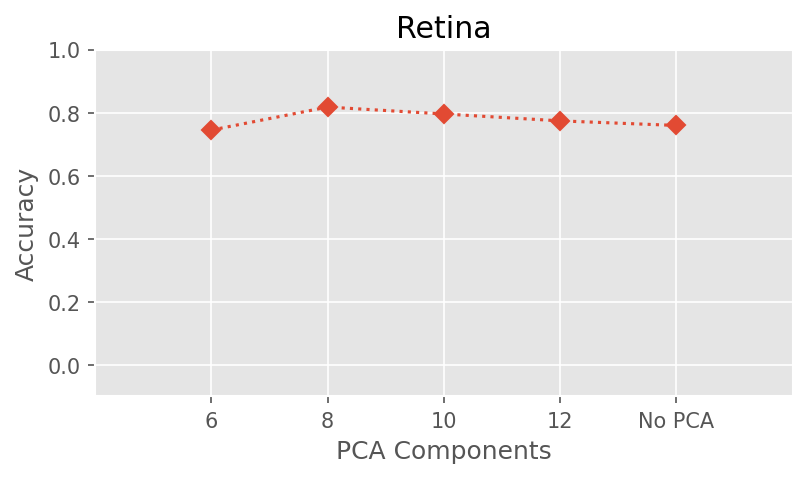

In [55]:
plt.style.use('ggplot')
fig = plt.figure(figsize = (6,3),dpi=150)
ax = plt.subplot(111)
ax.plot(range(1,6),results_rf,marker = 'D',linestyle = ':',label = 'Random Forest')
ax.set_xlim([0,6])
ax.set_xlabel('PCA Components')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(1,6))
ax.set_xticklabels(['6','8','10','12','No PCA'])
ax.set_ylim([-0.1,1])
ax.set_title('Retina')

In [56]:
results_rf

array([0.74452555, 0.81751825, 0.79562044, 0.77372263, 0.75912409])

In [57]:
fig.savefig('pca.png')

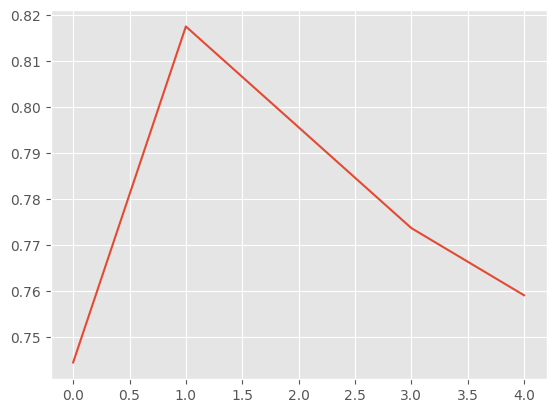

In [58]:
plt.plot(results_rf)

## Atividade

- Escolhe outra base de dados (https://scikit-learn.org/stable/api/sklearn.datasets.html);
- Classifique a base utilizando o GLCM.

Shape of images: (1797, 8, 8)
Shape of labels: (1797,)


<Figure size 640x480 with 0 Axes>

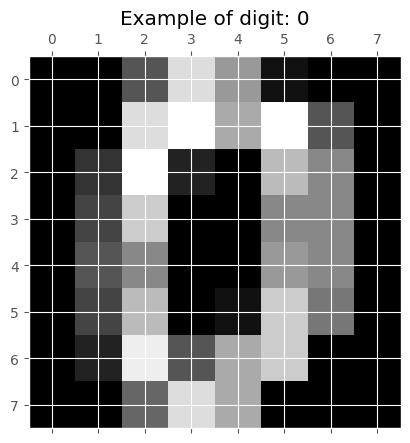

In [59]:
from sklearn.datasets import load_digits

digits = load_digits()
X_new = digits.images
y_new = digits.target

print(f"Shape of images: {X_new.shape}")
print(f"Shape of labels: {y_new.shape}")

# Display an example image
import matplotlib.pyplot as plt

plt.gray()
plt.matshow(X_new[0])
plt.title(f"Example of digit: {y_new[0]}")
plt.show()

In [60]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np
import time
from IPython.display import clear_output

# Scale images to 0-255 and convert to uint8
# The original digits images are 0-16. Scaling them to 0-255 makes them suitable for graycomatrix.
X_scaled = (X_new / X_new.max() * 255).astype(np.uint8)

d = 1  # Using d=1 for 8x8 images

# Initialize features array. Since it's grayscale, we'll have 6 features per image.
features_digits = np.zeros((len(X_scaled), 6))
start = time.time()

for id_im, imagem in enumerate(X_scaled):
    clear_output(wait=True)
    print(f'Extraindo atributos: {id_im+1} imagens processadas de {len(X_scaled)}.')

    # GLCM for grayscale image (single channel)
    # The level parameter should be adjusted based on the scaled pixel values.
    # For 0-255, 256 levels is appropriate.
    matrix0 = graycomatrix(imagem, [d], [0], levels=256, normed=True)
    matrix1 = graycomatrix(imagem, [d], [np.pi/4], levels=256, normed=True)
    matrix2 = graycomatrix(imagem, [d], [np.pi/2], levels=256, normed=True)
    matrix3 = graycomatrix(imagem, [d], [3*np.pi/4], levels=256, normed=True)
    matrix = (matrix0 + matrix1 + matrix2 + matrix3) / 4 # Isotropic GLCM

    props = np.zeros((6))
    props[0] = graycoprops(matrix, 'contrast')[0, 0]
    props[1] = graycoprops(matrix, 'dissimilarity')[0, 0]
    props[2] = graycoprops(matrix, 'homogeneity')[0, 0]
    props[3] = graycoprops(matrix, 'energy')[0, 0]
    props[4] = graycoprops(matrix, 'correlation')[0, 0]
    props[5] = graycoprops(matrix, 'ASM')[0, 0]
    features_digits[id_im, :] = props

end = time.time()
print(f"Tempo de extração de atributos: {end - start:.2f} segundos")
print(f"Shape dos atributos GLCM: {features_digits.shape}")

Extraindo atributos: 1797 imagens processadas de 1797.
Tempo de extração de atributos: 6.76 segundos
Shape dos atributos GLCM: (1797, 6)
